# Problématique métier
Une entreprise souhaite analyser les écarts de performance entre ses
départements en explorant les relations entre variables qualitatives
(départements, satisfaction) et quantitatives (scores de performance,
heures travaillées)

# EXPLORATION DES DONNEES

## Chargement des données

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import  stats
import scikit_posthocs as sp

df = pd.read_csv("projet 4.csv")
print("La dimension de la based de données est :", df.shape)
print("")
print("Aperçu des cinq première ligne")
df.head()

La dimension de la based de données est : (100000, 20)

Aperçu des cinq première ligne


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [4]:
print(df['Performance_Score'].unique())

[5 3 2 1 4]


In [5]:
# description de la base de données
print("===="*20)
print("              Information sur la base de données")
print("===="*20)
print(df.info())
print("")
print("===="*20)
print("                        type de données")
print("===="*20)
print(df.dtypes)
print("")

print("===="*20)
print("              Vérification de valeurs manquantes")
print("===="*20)
print(df.isnull().sum())
print("")

print("===="*20)
print("              Statistiques descriptives")
print("===="*20)
df.describe()

              Information sur la base de données
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_H

,Employee_ID,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,41.029410,4.476070,2.995430,6403.211000,44.956950,24.431170,14.514930,7.008550,50.090500,10.013560,49.506060,0.999720,2.999088
std,28867.657797,11.244121,2.869336,1.414726,1372.508717,8.942003,14.469584,8.664026,4.331591,35.351157,5.495405,28.890383,0.815872,1.150719
min,1.000000,22.000000,0.000000,1.000000,3850.000000,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,25000.750000,31.000000,2.000000,2.000000,5250.000000,37.000000,12.000000,7.000000,3.000000,25.000000,5.000000,25.000000,0.000000,2.010000
50%,50000.500000,41.000000,4.000000,3.000000,6500.000000,45.000000,24.000000,15.000000,7.000000,50.000000,10.000000,49.000000,1.000000,3.000000
75%,75000.250000,51.000000,7.000000,4.000000,7500.000000,53.000000,37.000000,22.000000,11.000000,75.000000,15.000000,75.000000,2.000000,3.990000
max,100000.000000,60.000000,10.000000,5.000000,9000.000000,60.000000,49.000000,29.000000,14.000000,100.000000,19.000000,99.000000,2.000000,5.000000


## Structures des données

In [6]:
print("===="*20)
print("              Les différents deprtements sont : ")
print("")
print(df["Department"].unique())
print("Il y a donc : ",df['Department'].nunique()," departements")
print("===="*20)
print("")
print("===="*20)
print("              Distrubition par departement (effectifs par departement) ")
print("===="*20)
df["Department"].value_counts()


              Les différents deprtements sont : 

['IT' 'Finance' 'Customer Support' 'Engineering' 'Marketing' 'HR'
 'Operations' 'Sales' 'Legal']
Il y a donc :  9  departements

              Distrubition par departement (effectifs par departement) 


Department
Marketing           11216
Finance             11200
Operations          11181
IT                  11131
Sales               11122
Legal               11118
Customer Support    11116
HR                  10960
Engineering         10956
Name: count, dtype: int64

## Statistiques descriptives clès

In [15]:
print("===="*20)
print("             Statistiue des performances par departement  ")
print("===="*20)
print(df.groupby("Department")["Performance_Score"].describe())
print("")
print("===="*20)
print("             Statistiue des satisfactions par departement  ")
print("===="*20)
print(df.groupby("Department")["Employee_Satisfaction_Score"].describe())

             Statistiue des performances par departement  
                    count      mean       std  min  25%  50%  75%  max
Department                                                            
Customer Support  11116.0  2.997121  1.414974  1.0  2.0  3.0  4.0  5.0
Engineering       10956.0  3.020263  1.415875  1.0  2.0  3.0  4.0  5.0
Finance           11200.0  2.981161  1.411971  1.0  2.0  3.0  4.0  5.0
HR                10960.0  2.997354  1.413533  1.0  2.0  3.0  4.0  5.0
IT                11131.0  3.000000  1.422386  1.0  2.0  3.0  4.0  5.0
Legal             11118.0  2.981741  1.423890  1.0  2.0  3.0  4.0  5.0
Marketing         11216.0  2.980653  1.406462  1.0  2.0  3.0  4.0  5.0
Operations        11181.0  3.006797  1.413438  1.0  2.0  3.0  4.0  5.0
Sales             11122.0  2.994336  1.410031  1.0  2.0  3.0  4.0  5.0

             Statistiue des satisfactions par departement  
                    count      mean       std  min     25%   50%   75%  max
Department             

## Visualisations initiales

Boxplot performance par departement


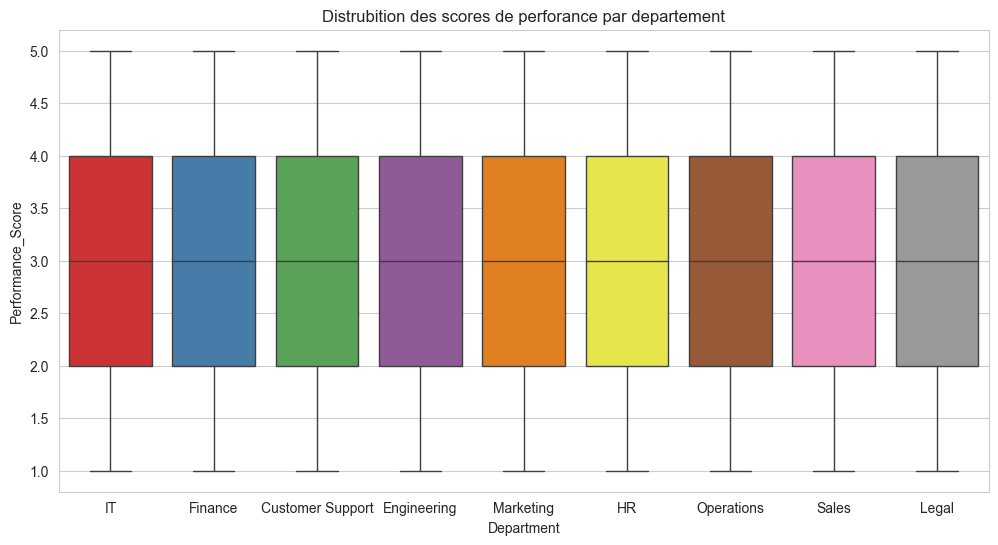

Boxplot satisfaction par departement


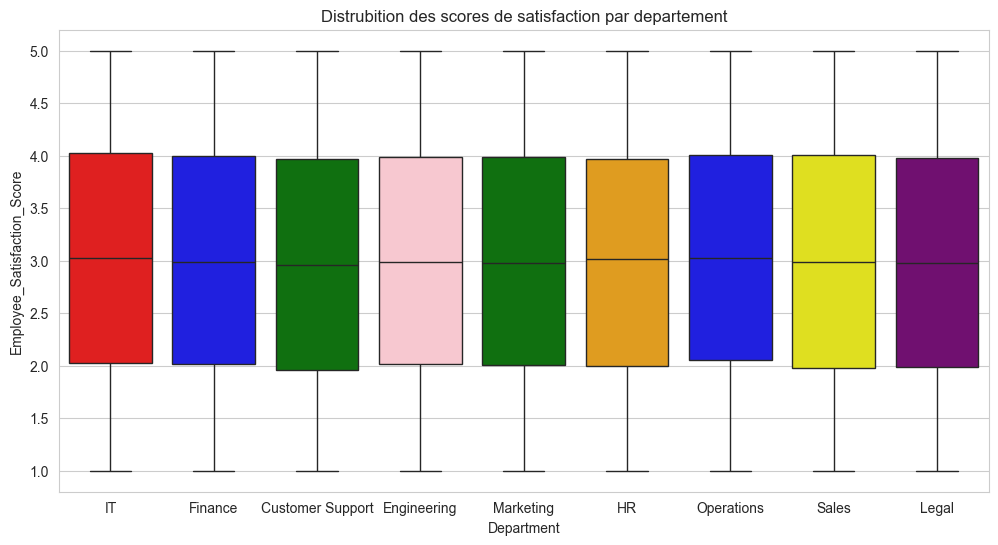

In [7]:
# configuration de notre style
sns.set_style("whitegrid")

print("==="*20)
print("Boxplot performance par departement")
print("==="*20)
plt.figure(figsize=(12,6))
sns.boxplot(x = "Department", y = "Performance_Score", data = df,hue = 'Department', palette = 'Set1')
plt.title('Distrubition des scores de perforance par departement')
plt.savefig('Boxplot performance par departemen.png', dpi=300, bbox_inches='tight')
plt.show()
print("==="*20)
print("Boxplot satisfaction par departement")
print("==="*20)
plt.figure(figsize=(12,6))
sns.boxplot(x = "Department", y = "Employee_Satisfaction_Score", data = df,hue = 'Department' ,palette = ["red","blue","green","pink","green","orange","blue","yellow","purple"])
plt.title('Distrubition des scores de satisfaction par departement')
plt.savefig('Boxplot satisfaction par departement.png', dpi=300, bbox_inches='tight')
plt.show()


### Test Statistique pour la vérification des hypthèses

In [8]:
print("==="*20)
print("           Kruskal-Wallis pour Performance vs Departement")

groups_perf = [group["Performance_Score"].values for name, group in df.groupby("Department")]
h_stat,p_value = stats.kruskal(*groups_perf)
print(f" Nous avons H = {h_stat:.3f} et la p_value = {p_value:.3f}")
print("==="*20)
print(" ")

print('==='*20)
print("          Kruskal-wallis pour la satisfaction vs departement")
group_sta = [group["Employee_Satisfaction_Score"].values for name,group in df.groupby("Department")]
h_stat_sat,p_value_sat = stats.kruskal(*group_sta)
print(f"  Nous obtenns H = {h_stat_sat:.3f} et p_value = {p_value_sat:.3f}")
print("==="*20)
print("==="*20)
print("           ")

           Kruskal-Wallis pour Performance vs Departement
 Nous avons H = 7.658 et la p_value = 0.468
 
          Kruskal-wallis pour la satisfaction vs departement
  Nous obtenns H = 21.639 et p_value = 0.006
           


In [9]:
print("Identification des departements qui diffèrent")

print("==="*20) 
print("Test post-hoc de Dum pour la satisfaction")
dunn_satisfaction = sp.posthoc_dunn(
    df, 
    val_col='Employee_Satisfaction_Score', 
    group_col='Department',
    p_adjust='bonferroni'  # Correction pour comparaisons multiples
)
print("")
print("==="*20)
print("     Affichage des paires significatives ")
signi = []
for i in range(len(dunn_satisfaction.index)) : 
    for j in range(i+1, len(dunn_satisfaction.columns)) : 
        p_val = dunn_satisfaction.iloc[i,j]
        if p_val < 0.05 :
            signi.append((dunn_satisfaction.index[i],
                        dunn_satisfaction.index[j],
                        p_val))

print("Paires significativement différentes : ")
for pair in signi : 
    print(f"{pair[0]} vs {[pair[1]]} : p = {pair[2]:.4f}")

Identification des departements qui diffèrent
Test post-hoc de Dum pour la satisfaction

     Affichage des paires significatives 
Paires significativement différentes : 
Customer Support vs ['IT'] : p = 0.0127
Customer Support vs ['Operations'] : p = 0.0063


In [10]:
print("==="*20)
print("Correlation entre la performance et la satisfaction")
corr,p = stats.pearsonr(df["Performance_Score"], df["Employee_Satisfaction_Score"])
print(f"la correlation entre la satisfaction et la performance est : {corr:.3f}, p = {p:.4f}")
print("==="*20)
print(" ")
print("==="*20)
print("Association entre l departement et la démission")
contigencyy = pd.crosstab(df["Department"], df["Resigned"])
chi2,p,dof,expected = stats.chi2_contingency(contigencyy)
print(f" Khi-deux Département VS Démission : X² = {chi2:.3f}, p = {p:.4f}")
print("==="*20)

Correlation entre la performance et la satisfaction
la correlation entre la satisfaction et la performance est : 0.002, p = 0.5917
 
Association entre l departement et la démission
 Khi-deux Département VS Démission : X² = 9.179, p = 0.3274


# Recherche D'autres facteurs explicatifs

In [11]:
# 1. Performance selon d'autres variables (ANOVA/Kruskal-Wallis)
# Test avec Promotions
groups_promo = [group['Performance_Score'].values for name, group in df.groupby('Promotions')]
h, p = stats.kruskal(*groups_promo)
print(f"Performance vs Promotions : H={h:.3f}, p={p:.4f}")

# 2. Démission selon le salaire (Test de Mann-Whitney)
resigned_salary = df[df['Resigned']==1]['Monthly_Salary']
not_resigned_salary = df[df['Resigned']==0]['Monthly_Salary']
stat, p = stats.mannwhitneyu(resigned_salary, not_resigned_salary)
print(f"Salaire vs Démission : U={stat:.0f}, p={p:.4f}")

# 3. Corrélations avec Performance
corr_matrix = df[['Performance_Score', 'Work_Hours_Per_Week', 
                  'Training_Hours', 'Projects_Handled', 
                  'Overtime_Hours', 'Team_Size']].corr()
print("\nCorrélations avec Performance :")
print(corr_matrix['Performance_Score'].sort_values(ascending=False))

Performance vs Promotions : H=3.279, p=0.1941
Salaire vs Démission : U=449029592, p=0.6166

Corrélations avec Performance :
Performance_Score      1.000000
Training_Hours         0.002358
Projects_Handled       0.000640
Overtime_Hours        -0.001312
Team_Size             -0.005174
Work_Hours_Per_Week   -0.005627
Name: Performance_Score, dtype: float64


## Analyse des facteurs de performances

In [12]:
# Nous utiliserons une régression linéaire multiple pour identifier ce qui influence réellement.

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
import statsmodels.api as sm

# preparation des données
df_enc = df.copy()
# Encodage des variables catégorielles
le = LabelEncoder()
categorical_cols = ['Department', 'Gender', 'Job_Title', 'Education_Level', 'Remote_Work_Frequency']

for col in categorical_cols : 
    df_enc[col] = le.fit_transform(df_enc[col])

# Sélection des features pour la performance
features = ['Age', 'Years_At_Company', 'Monthly_Salary', 'Work_Hours_Per_Week',
            'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Team_Size',
            'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score',
            'Department', 'Gender', 'Education_Level', 'Remote_Work_Frequency']

# Séparation des base de données par les features et la variable explicative
X = df_enc[features]
y = df['Performance_Score']

# Split et Scaling
X_train, X_test,y_train,y_test = train_test_split(X,y, test_size= 0.3,random_state= 42)

sacler = StandardScaler()
X_train_scaler = sacler.fit_transform(X_train)
X_test_scaler = sacler.fit_transform(X_test)

# Regression avec statsmodels
X_sm = sm.add_constant(X_train)
model = sm.OLS(y_train,X_sm).fit()
print("Les  résultats de la régression")
print(model.summary().tables[1]) 

# Evaluation 
lr = LinearRegression()
lr.fit(X_train_scaler, y_train)
y_pred = lr.predict(X_test_scaler)
print("==="*10, "Les résultats de la régression","==="*10)
print(f" Le R² = {r2_score(y_test,y_pred):.3f}")
print(f" RMSE = {mean_squared_error(y_test, y_pred):.3f} ")
print("==="*30)

Les  résultats de la régression
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -0.3357      0.044     -7.589      0.000      -0.422      -0.249
Age                            -0.0001      0.000     -0.292      0.770      -0.001       0.001
Years_At_Company                0.0011      0.002      0.663      0.507      -0.002       0.004
Monthly_Salary                  0.0005   3.35e-06    156.457      0.000       0.001       0.001
Work_Hours_Per_Week            -0.0005      0.001     -0.981      0.327      -0.002       0.001
Projects_Handled            -9.761e-05      0.000     -0.307      0.759      -0.001       0.001
Overtime_Hours                 -0.0001      0.001     -0.191      0.848      -0.001       0.001
Sick_Days                     6.28e-05      0.001      0.059      0.953      -0.002       0.002
Team_Siz

## Analyse des facteurs de démissions

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Variables pour la démission
features_resign = ['Age', 'Years_At_Company', 'Monthly_Salary', 'Performance_Score',
                   'Work_Hours_Per_Week', 'Overtime_Hours', 'Sick_Days',
                   'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score',
                   'Department', 'Gender', 'Education_Level']

X_resign = df_enc[features_resign]
y_resign = df_enc['Resigned']

# Split et scaling
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_resign, y_resign, test_size=0.3, random_state=42)
X_train_r_scaled = sacler.fit_transform(X_train_r)
X_test_r_scaled = sacler.transform(X_test_r)

# Régression logistique
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_r_scaled, y_train_r)
y_pred_r = logreg.predict(X_test_r_scaled)

# Évaluation
print("==="*9, "Les résultats de la régression logistiques", "==="*9)
print(f"Accuracy : {logreg.score(X_test_r_scaled, y_test_r):.3f}")
print(f"AUC-ROC : {roc_auc_score(y_test_r, y_pred_r):.3f}")
print(" ")
print("==="*10,"Rapport de classification :","==="*10)
print(classification_report(y_test_r, y_pred_r))

# Coefficients importants
coef_df = pd.DataFrame({
    'Feature': features_resign,
    'Coefficient': logreg.coef_[0],
    'Abs_Coefficient': np.abs(logreg.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("=="*10," Facteurs les plus influents sur la démission :","=="*9)
print(" ")
print(coef_df)

=========================== Les résultats de la régression logistiques ===========================
Accuracy : 0.899
AUC-ROC : 0.500
 
============================== Rapport de classification : ==============================
              precision    recall  f1-score   support

       False       0.90      1.00      0.95     26969
        True       0.00      0.00      0.00      3031

    accuracy                           0.90     30000
   macro avg       0.45      0.50      0.47     30000
weighted avg       0.81      0.90      0.85     30000

====================  Facteurs les plus influents sur la démission : ==================
 
                        Feature  Coefficient  Abs_Coefficient
8                    Promotions    -0.008856         0.008856
9   Employee_Satisfaction_Score    -0.008577         0.008577
2                Monthly_Salary    -0.008221         0.008221
5                Overtime_Hours     0.007714         0.007714
6                     Sick_Days     0.006323     

C:\Users\Utilisateur\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Utilisateur\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Utilisateur\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

## Analyse par segmentation
nous allons régrouper les employés par profil pour identifier les segments homogènes.

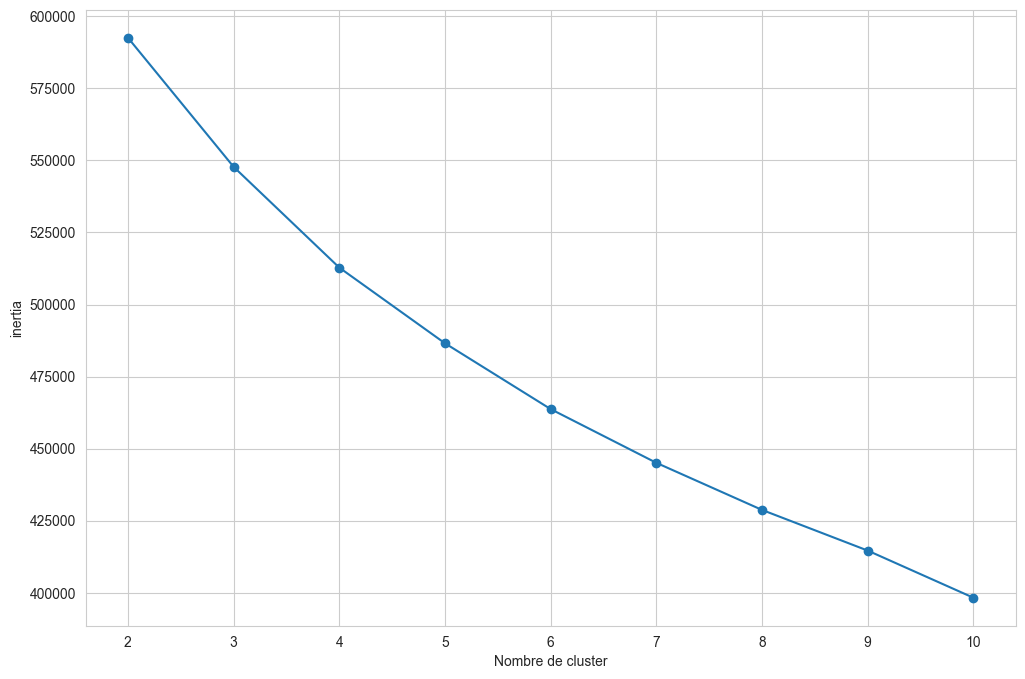

In [15]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Selaction des varibles pour le clustering
cluster_var = ['Age', 'Years_At_Company', 'Monthly_Salary', 'Performance_Score',
                'Work_Hours_Per_Week', 'Training_Hours', 'Employee_Satisfaction_Score']
X_cluster = df_enc[cluster_var]

# Standarisation
scaler = StandardScaler()
X_cluster_scaler = scaler.fit_transform(X_cluster)

# Derterminantion du nombre de cluster (Nous ferons la methode de coude pour ceux qui ne connaissent pas)
# Pour cette methode je vais commenter les lignes pour vous qui ne maitriser pas
# Si tu sais que tu maitrise tu n'es pas concerné par les commentaires

inertia = [] #Création de la liste 
for k in range(2,11) : # Nous faisons varier un compteur entre 2 et 10 (ce sont nos potentiels valeures)
    kmeans = KMeans(n_clusters= k,random_state=42) # le test de chaque valeur du compteur k
    kmeans.fit(X_cluster_scaler)
    inertia.append(kmeans.inertia_) # Nous mettons les résultats dans la liste afin de les visualiser

plt.figure(figsize=(12,8))
plt.plot(range(2,11), inertia, marker = 'o') # bon ça c'est juste le graphe en fait
plt.xlabel("Nombre de cluster")
plt.ylabel("inertia")
plt.savefig('Methode du coude.png', dpi=300, bbox_inches='tight')
plt.show()


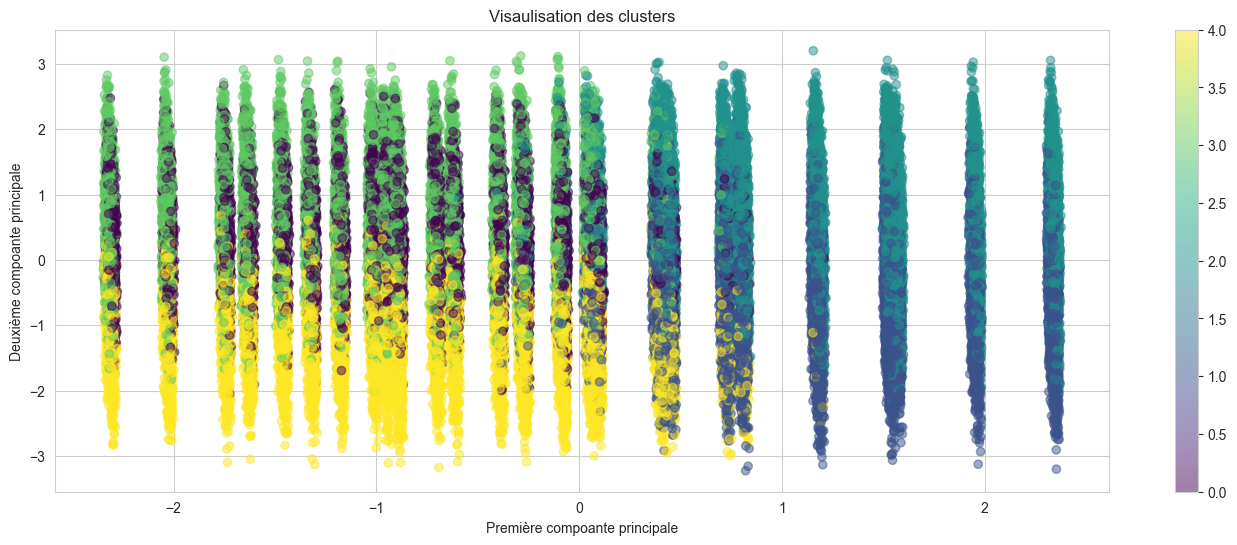

============================== Voilà le profil moyen par cluster ==============================


,Age,Years_At_Company,Monthly_Salary,Performance_Score,Work_Hours_Per_Week,Training_Hours,Employee_Satisfaction_Score
cluster,,,,,,,
0,41.12,7.30,5682.20,2.17,44.97,49.72,3.82
1,41.10,4.50,7460.53,4.23,44.71,22.40,2.91
2,41.27,4.52,7471.40,4.23,45.02,76.62,2.90
3,40.70,4.44,5557.53,1.99,45.07,49.44,1.78
4,40.97,1.70,5698.23,2.19,45.01,49.42,3.85


In [16]:
# D'après la visualisatioon le meilleur k est 5

kmeans = KMeans(n_clusters= 5, random_state= 42, n_init= 10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaler)

# Visualisation avec PCA

pca = PCA(n_components= 2)
resul = pca.fit_transform(X_cluster_scaler)

plt.figure(figsize= (17,6))
scatter = plt.scatter(resul[:,0], resul[:,1], c = df['cluster'], cmap = 'viridis', alpha = 0.5)
plt.colorbar(scatter)
plt.title('Visaulisation des clusters')
plt.xlabel("Première compoante principale")
plt.ylabel("Deuxième compoante principale")
plt.savefig('Visaulisation des clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# Profil de chaque cluster

cluster_profil = df.groupby('cluster')[cluster_var].mean()
print("==="*10, "Voilà le profil moyen par cluster", "==="*10)
cluster_profil.round(2)

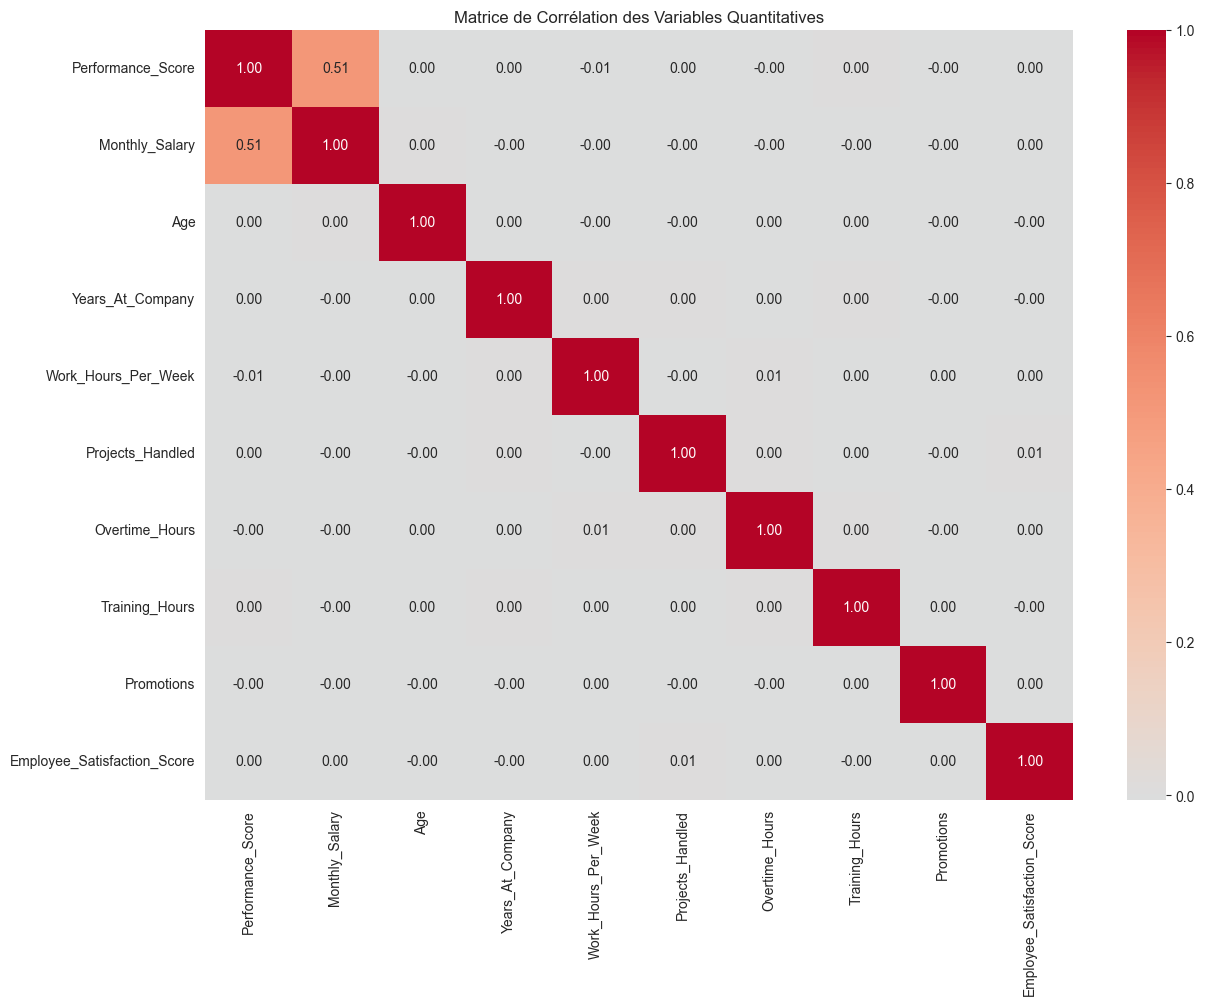

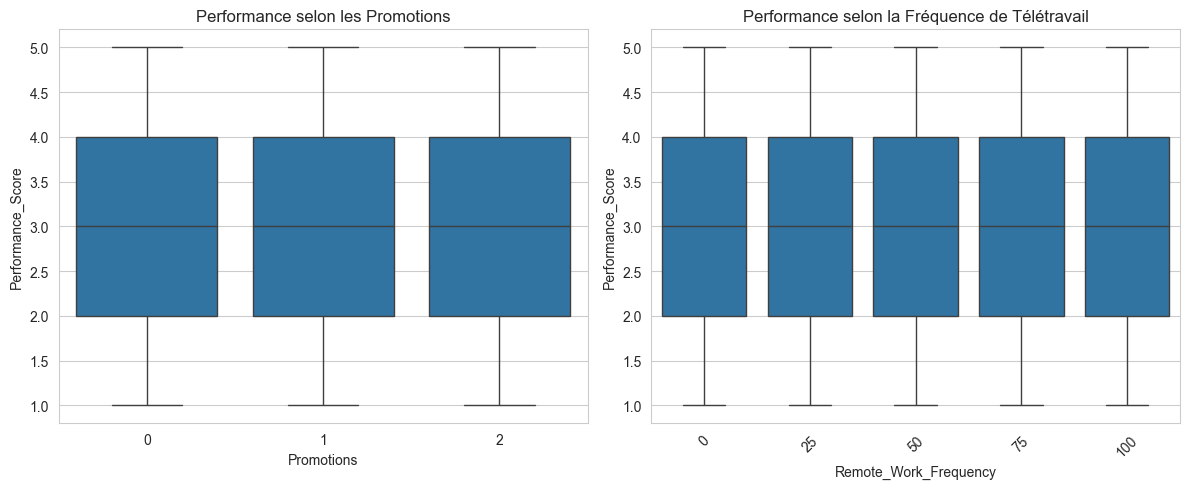

In [17]:
# Matrice de corrélation complète
plt.figure(figsize=(14, 10))
corr_matrix_full = df[['Performance_Score', 'Monthly_Salary', 'Age', 
                       'Years_At_Company', 'Work_Hours_Per_Week', 
                       'Projects_Handled', 'Overtime_Hours', 
                       'Training_Hours', 'Promotions', 
                       'Employee_Satisfaction_Score']].corr()
sns.heatmap(corr_matrix_full, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matrice de Corrélation des Variables Quantitatives')
plt.savefig('Matrice de Corrélation des Variables Quantitatives.png', dpi=300, bbox_inches='tight')
plt.show()

# Performance selon le nombre de promotions
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Promotions', y='Performance_Score', data=df)
plt.title('Performance selon les Promotions')

plt.subplot(1, 2, 2)
sns.boxplot(x='Remote_Work_Frequency', y='Performance_Score', data=df)
plt.title('Performance selon la Fréquence de Télétravail')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Performance selon la Fréquence de Télétravail.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# ANOVA à 2 facteurs (Département x Promotions)
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

model_interaction = ols('Performance_Score ~ C(Department) * C(Promotions)', data=df).fit()
anova_results = anova_lm(model_interaction)

print(" ANOVA (Département * Promotions)")
anova_results

 ANOVA (Département * Promotions)


,df,sum_sq,mean_sq,F,PR(>F)
C(Department),8.0,15.332150,1.916519,0.957534,0.467345
C(Promotions),2.0,6.615021,3.307511,1.652504,0.191575
C(Department):C(Promotions),16.0,23.575969,1.473498,0.736192,0.759035
Residual,99973.0,200097.388370,2.001514,NaN,NaN
